# COVID-19 Data Analysis and Forecasting Project

Project Description:
This project performs COVID-19 data analysis,
visualization, and forecasting using Python libraries
like Pandas, Matplotlib, Seaborn, and Prophet.

Features:
- Data Cleaning
- Data Visualization
- Country-wise Analysis
- Time Series Forecasting

Author: Disha Kataria


In [ ]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load Dataset
 = pd.read_csv('Covid_19_Clean_Complete.csv')

In [ ]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


### Dataset Information

In [ ]:
df.shape

(49068, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [ ]:
# Rename Columns
df.rename(columns = {
    "Province/State" : "State",
    "Country/Region" : "Country"
}, inplace = True)

In [ ]:
df

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [ ]:
# Date Analysis
df['Date'].value_counts() # On each date, how many data points are recorded.

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


In [ ]:
df['Date'].max() # Last date recorded

'2020-07-27'

In [ ]:
# Country-wise Summary
df.groupby(['Country'])[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,1936390,49098,798240,1089052
1,Albania,196702,5708,118877,72117
2,Algeria,1179755,77972,755897,345886
3,Andorra,94404,5423,69074,19907
4,Angola,22662,1078,6573,15011
...,...,...,...,...,...
182,West Bank and Gaza,233461,1370,61124,170967
183,Western Sahara,901,63,648,190
184,Yemen,67180,17707,23779,25694
185,Zambia,129421,2643,83611,43167


In [ ]:
# Latest Date Records
top_date = df[df['Date'] == df['Date'].max()]

In [ ]:
top_date.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,NaN,Afghanistan,33.93911,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,NaN,Albania,41.15330,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,NaN,Algeria,28.03390,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,NaN,Andorra,42.50630,1.521800,2020-07-27,907,52,803,52,Europe
48811,NaN,Angola,-11.20270,17.873900,2020-07-27,950,41,242,667,Africa


In [ ]:
top_date.groupby(['Country'])[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,36263,1269,25198,9796
1,Albania,4880,144,2745,1991
2,Algeria,27973,1163,18837,7973
3,Andorra,907,52,803,52
4,Angola,950,41,242,667
...,...,...,...,...,...
182,West Bank and Gaza,10621,78,3752,6791
183,Western Sahara,10,1,8,1
184,Yemen,1691,483,833,375
185,Zambia,4552,140,2815,1597


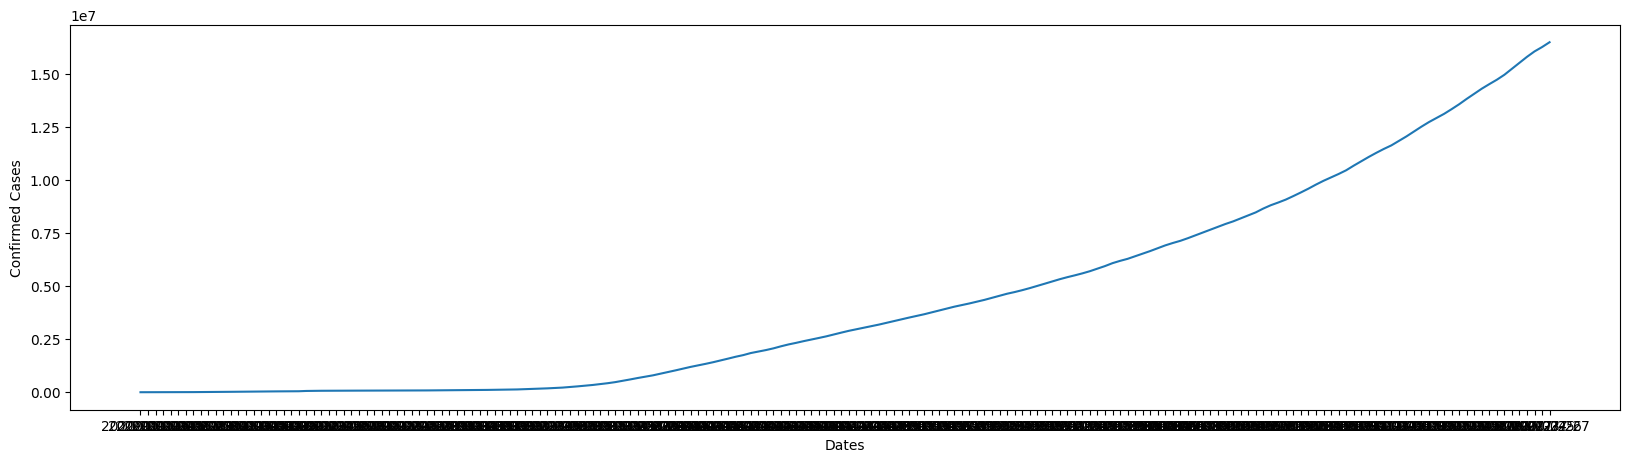

In [ ]:
# Confirmed Cases Visualization
confirmed_cases = df.groupby(['Date'])['Confirmed'].sum().reset_index()
plt.figure(figsize = (20,5))
sns.lineplot(data = confirmed_cases, x = 'Date', y = 'Confirmed')
plt.xlabel('Dates')
plt.ylabel('Confirmed Cases')
plt.show()

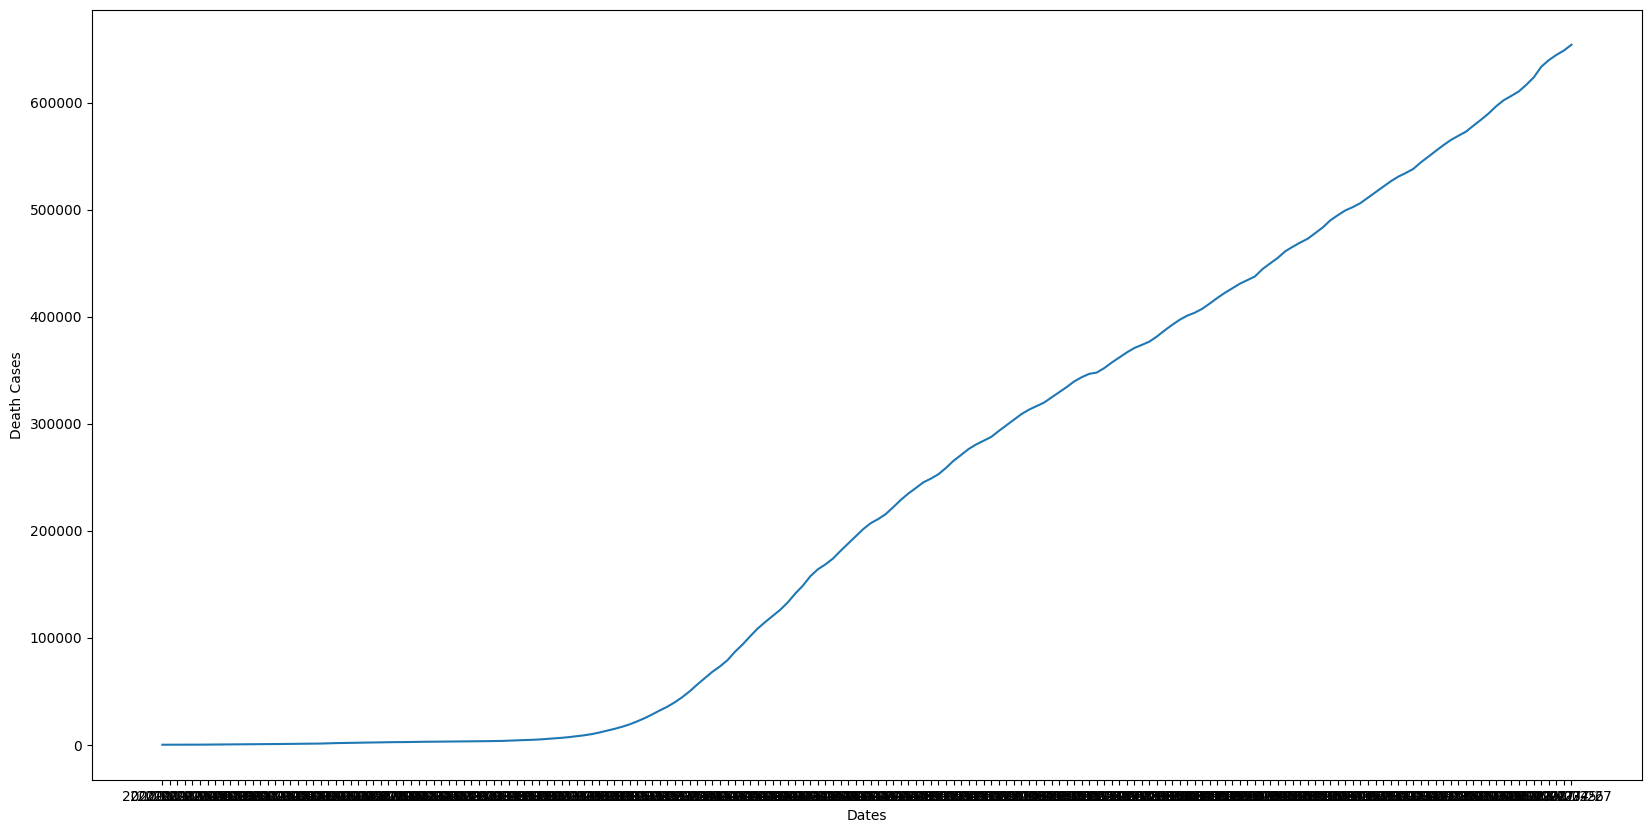

In [ ]:
# Death Cases Visualization
deaths_cases = df.groupby(['Date'])['Deaths'].sum().reset_index()
plt.figure(figsize = (20,10))
sns.lineplot(data = deaths_cases, x = 'Date', y = 'Deaths')
plt.xlabel('Dates')
plt.ylabel('Death Cases')
plt.show()

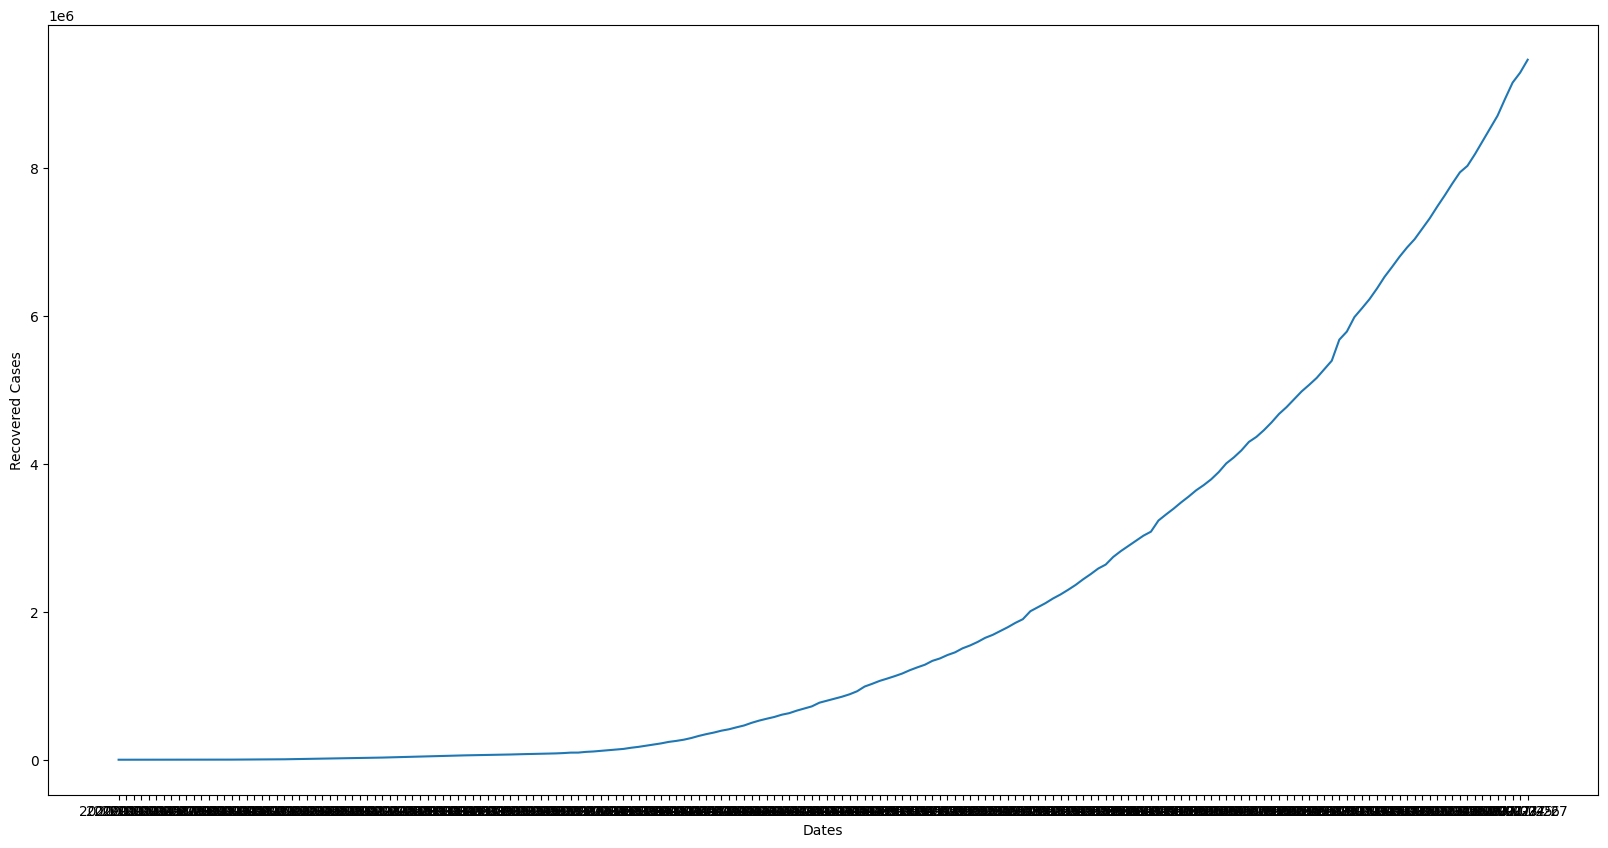

In [ ]:
# Recovered Cases Visualization
recovered_cases = df.groupby(['Date'])['Recovered'].sum().reset_index()
plt.figure(figsize = (20,10))
sns.lineplot(data = recovered_cases, x = 'Date', y = 'Recovered')
plt.xlabel('Dates')
plt.ylabel('Recovered Cases')
plt.show()

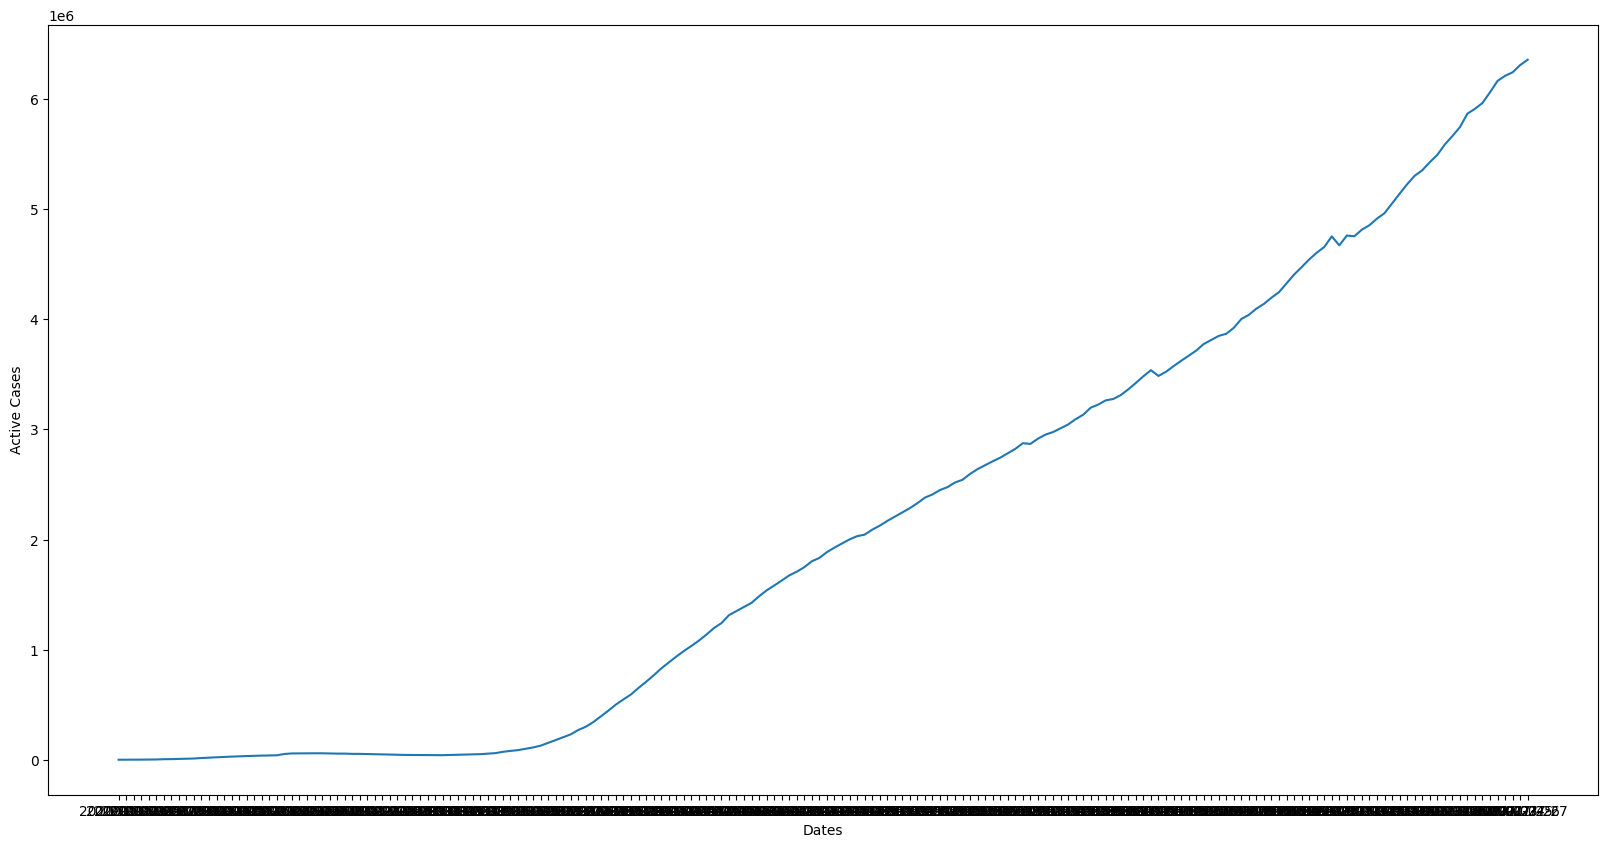

In [ ]:
# Active Cases Visualization
active_cases = df.groupby(['Date'])['Active'].sum().reset_index()
plt.figure(figsize = (20,10))
sns.lineplot(data = active_cases, x = 'Date', y = 'Active')
plt.xlabel('Dates')
plt.ylabel('Active Cases')
plt.show()

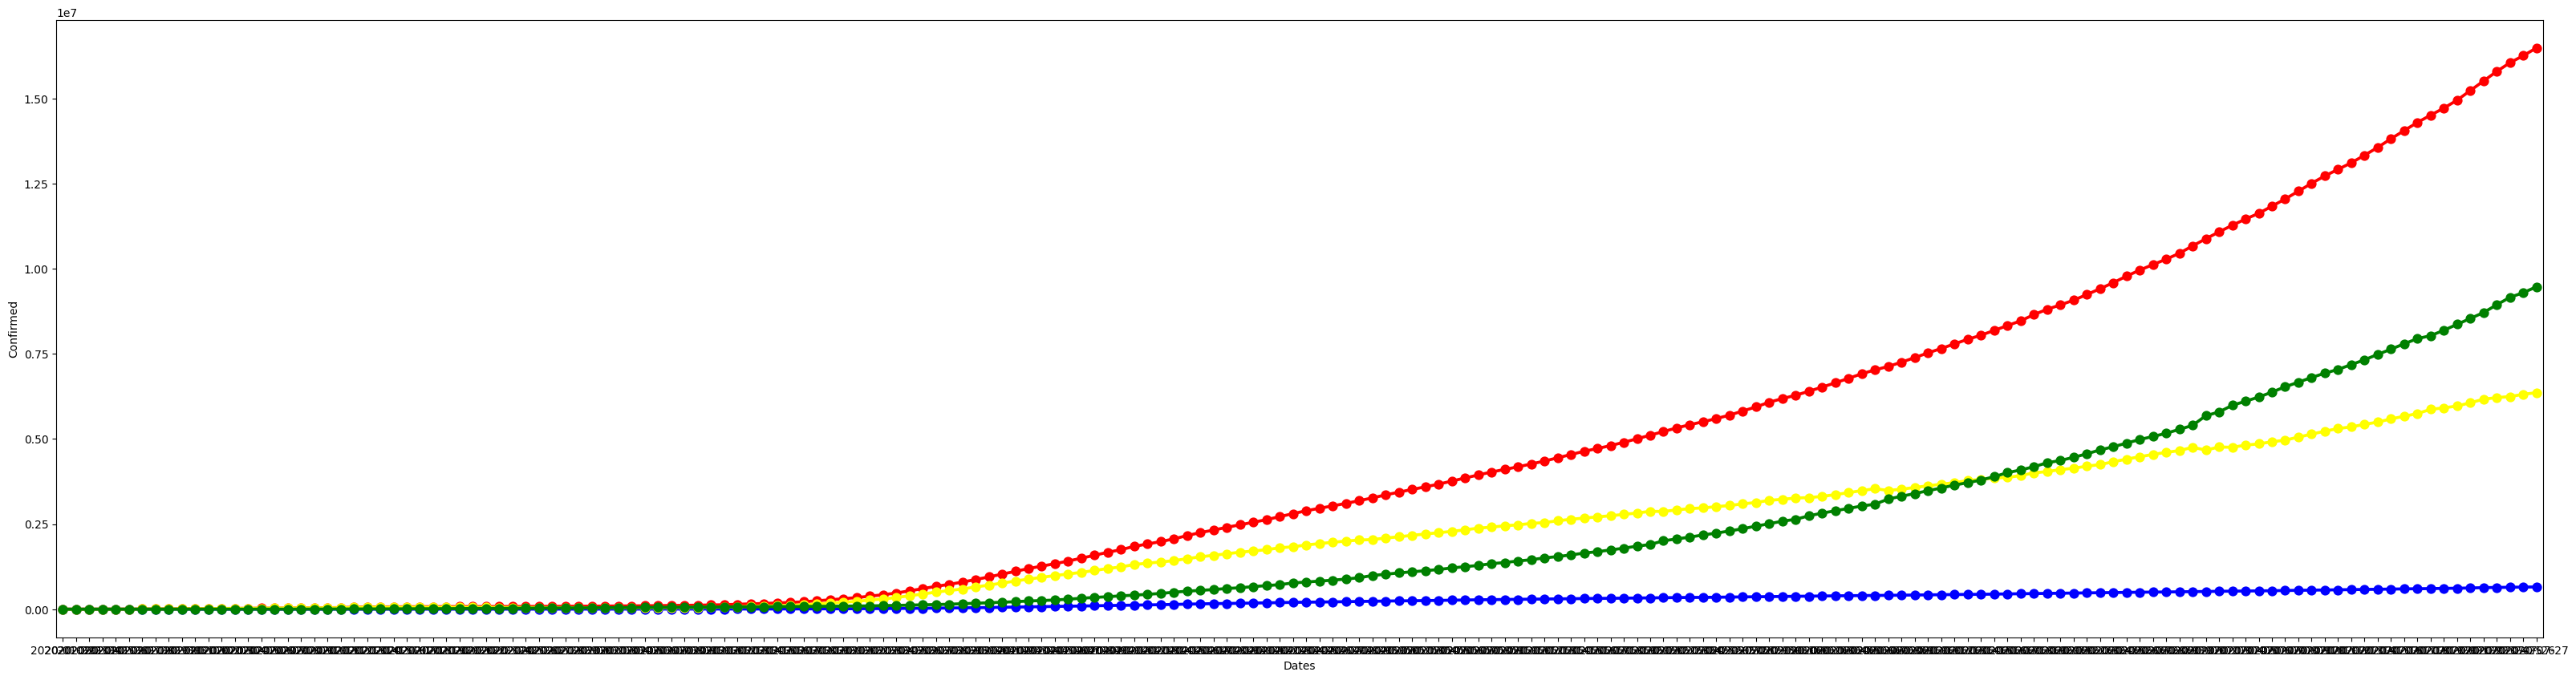

In [ ]:
plt.figure(figsize = (40, 10))
sns.pointplot(data = confirmed_cases, x = 'Date', y = 'Confirmed', color = 'Red')
sns.pointplot(data = deaths_cases, x = 'Date', y = 'Deaths', color = 'Blue')
sns.pointplot(data = active_cases, x = 'Date', y = 'Active', color = 'Yellow')
sns.pointplot(data = recovered_cases, x = 'Date', y = 'Recovered', color = 'Green')
plt.xlabel('Dates')
plt.show()

## Top 3 Most Affected Countries
1. US
2. China
3. India

In [ ]:
US = df[df['Country'] == 'US']
US = US.groupby(['Date'])[['Confirmed', 'Active', 'Recovered', 'Deaths']].sum().reset_index()
US

,Date,Confirmed,Active,Recovered,Deaths
0,2020-01-22,1,1,0,0
1,2020-01-23,1,1,0,0
2,2020-01-24,2,2,0,0
3,2020-01-25,2,2,0,0
4,2020-01-26,5,5,0,0
...,...,...,...,...,...
183,2020-07-23,4038816,2661117,1233269,144430
184,2020-07-24,4112531,2705347,1261624,145560
185,2020-07-25,4178970,2753091,1279414,146465
186,2020-07-26,4233923,2789125,1297863,146935


In [ ]:
China = df[df['Country'] == 'China']
China = China.groupby(['Date'])[['Confirmed', 'Active', 'Recovered', 'Deaths']].sum().reset_index()
China

,Date,Confirmed,Active,Recovered,Deaths
0,2020-01-22,548,503,28,17
1,2020-01-23,643,595,30,18
2,2020-01-24,920,858,36,26
3,2020-01-25,1406,1325,39,42
4,2020-01-26,2075,1970,49,56
...,...,...,...,...,...
183,2020-07-23,86045,2695,78701,4649
184,2020-07-24,86202,2807,78745,4650
185,2020-07-25,86381,2916,78813,4652
186,2020-07-26,86570,3056,78862,4652


In [ ]:
India = df[df['Country'] == 'India']
India = India.groupby(['Date'])[['Confirmed', 'Active', 'Recovered', 'Deaths']].sum().reset_index()
India

,Date,Confirmed,Active,Recovered,Deaths
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,1288108,440298,817209,30601
184,2020-07-24,1337024,456234,849432,31358
185,2020-07-25,1385635,468002,885573,32060
186,2020-07-26,1435616,485277,917568,32771


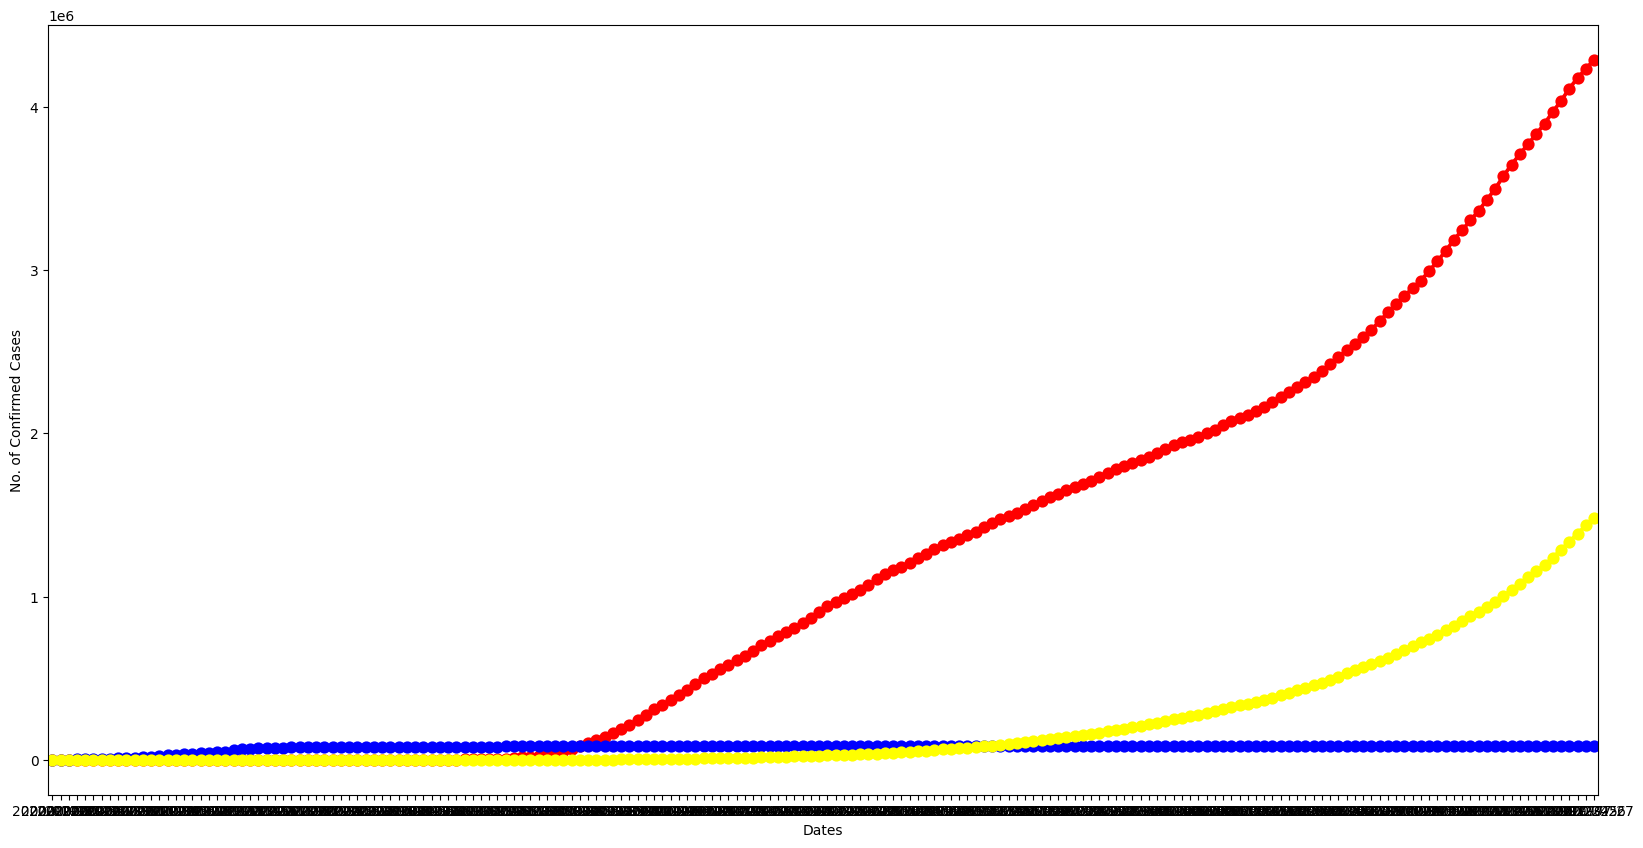

In [ ]:
plt.figure(figsize = (20, 10))
sns.pointplot(data = US, x = 'Date', y = 'Confirmed', color = 'Red')
sns.pointplot(data = China, x = 'Date', y = 'Confirmed', color = 'Blue')
sns.pointplot(data = India, x = 'Date', y = 'Confirmed', color = 'Yellow')

plt.ylabel('No. of Confirmed Cases')
plt.xlabel('Dates')
plt.show()

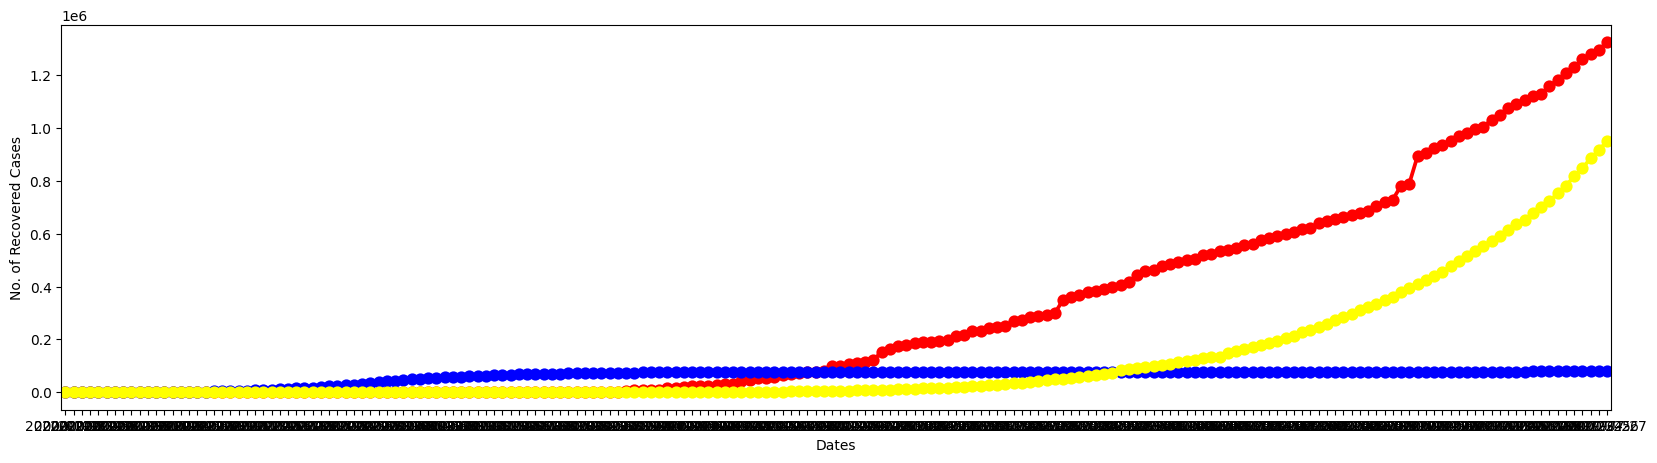

In [ ]:
plt.figure(figsize=(20,5))
sns.pointplot(data=US,x='Date',y='Recovered',color='Red')
sns.pointplot(data=China,x='Date',y='Recovered',color='Blue')
sns.pointplot(data=India,x='Date',y='Recovered',color='Yellow')

plt.ylabel('No. of Recovered Cases')
plt.xlabel('Dates')
plt.show()

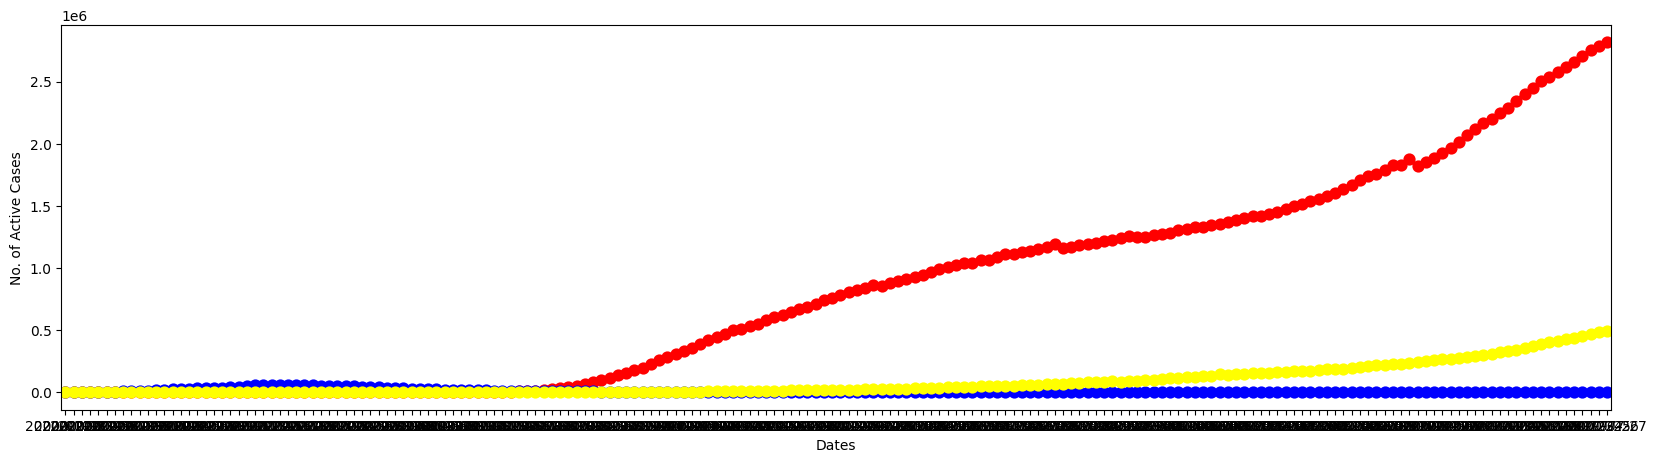

In [ ]:
plt.figure(figsize=(20,5))
sns.pointplot(data=US,x='Date',y='Active',color='Red')
sns.pointplot(data=China,x='Date',y='Active',color='Blue')
sns.pointplot(data=India,x='Date',y='Active',color='Yellow')

plt.ylabel('No. of Active Cases')
plt.xlabel('Dates')
plt.show()

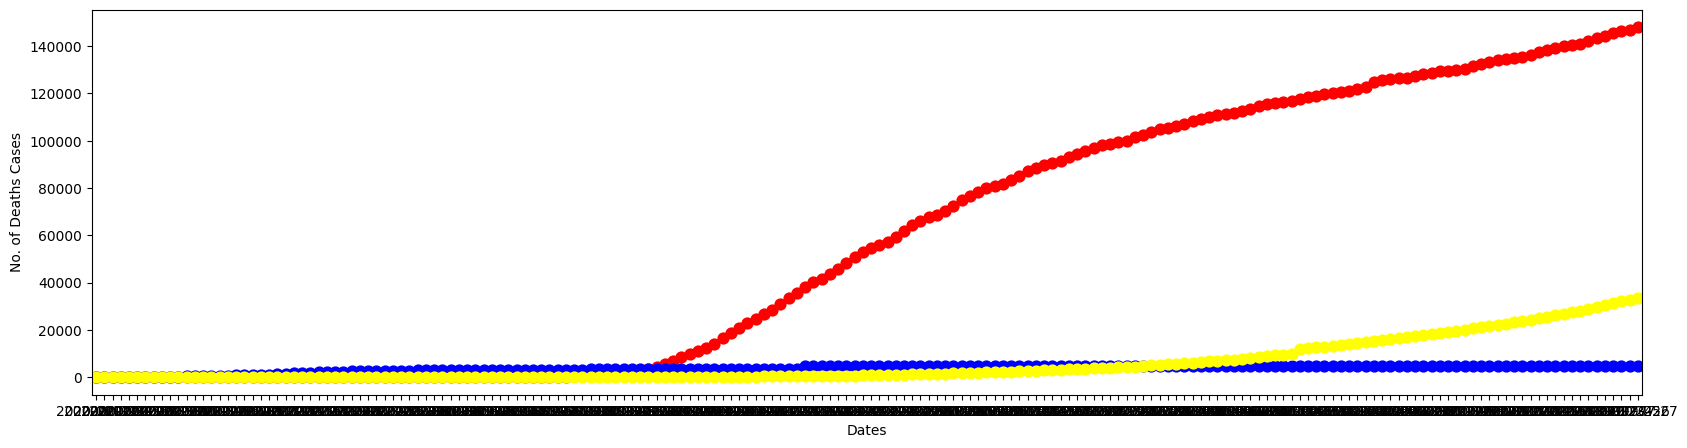

In [ ]:
plt.figure(figsize=(20,5))
sns.pointplot(data=US,x='Date',y='Deaths',color='Red')
sns.pointplot(data=China,x='Date',y='Deaths',color='Blue')
sns.pointplot(data=India,x='Date',y='Deaths',color='Yellow')

plt.ylabel('No. of Deaths Cases')
plt.xlabel('Dates')
plt.show()

# Model Bulding

## Install Prophet (Run only once)
### !pip install prophet
'''
Prophet is a time series forecasting tool developed by Facebook that’s designed to be easy to use and effective for a wide range
of time series data. It’s particularly useful for data that has strong seasonal effects (like daily or weekly patterns) and includes
important dates or events that can impact the forecast.
'''


In [ ]:
# Install Prophet (Run only once)

# !pip install prophet

In [ ]:
# Forecasting Preparation
confirmed_cases=df.groupby(['Date']).sum()['Confirmed'].reset_index()
confirmed_cases.columns = ['ds', 'y']
confirmed_cases

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [ ]:
from prophet import Prophet

In [ ]:
# Build Forecasting Model
model = Prophet()
model.fit(confirmed_cases)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
# Future Prediction
future = model.make_future_dataframe(periods = 7)
forecasted = model.predict(future)
forecasted

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.613288e+03,-1.228322e+05,8.379773e+04,-9.613288e+03,-9.613288e+03,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-2.067685e+04
1,2020-01-23,-6.933409e+03,-1.141267e+05,9.617017e+04,-6.933409e+03,-6.933409e+03,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8.050953e+03
2,2020-01-24,-4.253530e+03,-9.736927e+04,1.126487e+05,-4.253530e+03,-4.253530e+03,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5.827449e+03
3,2020-01-25,-1.573651e+03,-9.636600e+04,1.233521e+05,-1.573651e+03,-1.573651e+03,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.217668e+04
4,2020-01-26,1.106228e+03,-9.943264e+04,1.180643e+05,1.106228e+03,1.106228e+03,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8.405020e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674503e+07,1.664265e+07,1.685841e+07,1.673966e+07,1.675321e+07,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,1.674392e+07
191,2020-07-31,1.694902e+07,1.684618e+07,1.706684e+07,1.693688e+07,1.696547e+07,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,1.695911e+07
192,2020-08-01,1.715301e+07,1.706792e+07,1.727905e+07,1.713434e+07,1.718148e+07,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,1.716677e+07
193,2020-08-02,1.735701e+07,1.725920e+07,1.747452e+07,1.733124e+07,1.739510e+07,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,1.736430e+07


In [ ]:
forecasted[['yhat_lower','yhat','yhat_upper']]

,yhat_lower,yhat,yhat_upper
0,-1.228322e+05,-2.067685e+04,8.379773e+04
1,-1.141267e+05,-8.050953e+03,9.617017e+04
2,-9.736927e+04,5.827449e+03,1.126487e+05
3,-9.636600e+04,1.217668e+04,1.233521e+05
4,-9.943264e+04,8.405020e+03,1.180643e+05
...,...,...,...
190,1.664265e+07,1.674392e+07,1.685841e+07
191,1.684618e+07,1.695911e+07,1.706684e+07
192,1.706792e+07,1.716677e+07,1.727905e+07
193,1.725920e+07,1.736430e+07,1.747452e+07


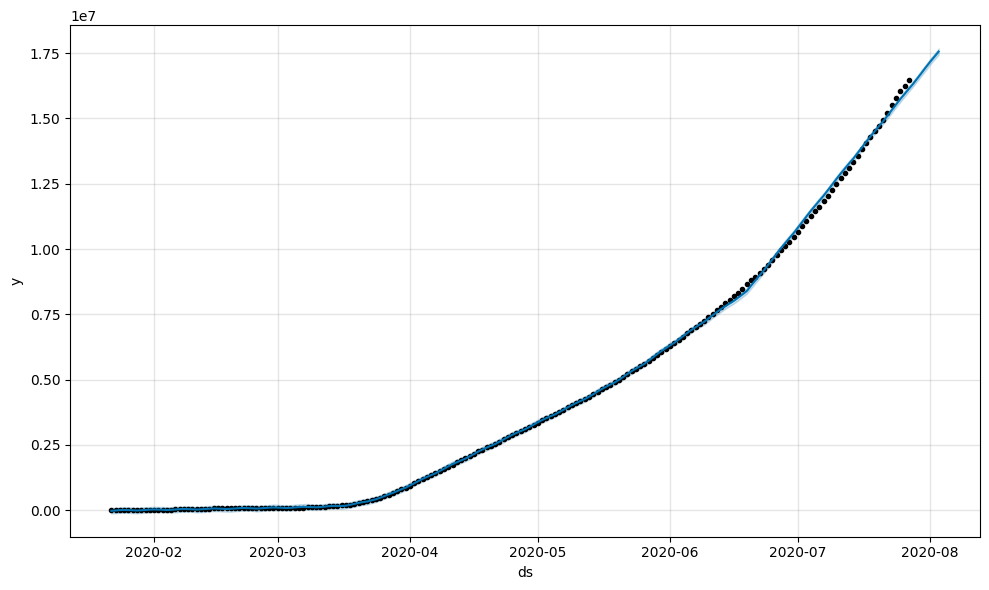

In [ ]:
model.plot(forecasted)
plt.show()

In [ ]:
recovered_cases.columns = ['ds', 'y']

model_recovered = Prophet()
model_recovered.fit(recovered_cases)
future = model_recovered.make_future_dataframe(periods = 7)
forecasted = model_recovered.predict(future)
forecasted

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-1.360144e+04,-9.156638e+04,6.024504e+04,-1.360144e+04,-1.360144e+04,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,-4840.633687,0.0,0.0,0.0,-1.844208e+04
1,2020-01-23,-1.243662e+04,-9.646641e+04,6.855829e+04,-1.243662e+04,-1.243662e+04,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,-1.118182e+04
2,2020-01-24,-1.127180e+04,-8.732630e+04,7.009888e+04,-1.127180e+04,-1.127180e+04,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,-5.175647e+03
3,2020-01-25,-1.010697e+04,-8.000319e+04,7.371192e+04,-1.010697e+04,-1.010697e+04,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,-4.075311e+02
4,2020-01-26,-8.942151e+03,-9.350928e+04,6.610205e+04,-8.942151e+03,-8.942151e+03,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,-9.825630e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,9.594538e+06,9.513323e+06,9.677419e+06,9.590740e+06,9.597912e+06,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,1254.797967,0.0,0.0,0.0,9.595793e+06
191,2020-07-31,9.731096e+06,9.659351e+06,9.818329e+06,9.722825e+06,9.738233e+06,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,6096.150124,0.0,0.0,0.0,9.737193e+06
192,2020-08-01,9.867654e+06,9.797008e+06,9.955412e+06,9.853320e+06,9.880354e+06,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,9699.442818,0.0,0.0,0.0,9.877354e+06
193,2020-08-02,1.000421e+07,9.913423e+06,1.008533e+07,9.984216e+06,1.002187e+07,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,-883.479296,0.0,0.0,0.0,1.000333e+07


In [ ]:
active_cases = df.groupby(['Date'])['Active'].sum().reset_index()
active_cases.columns = ['ds', 'y']

model_active = Prophet()
model_active.fit(active_cases)

future = model_active.make_future_dataframe(periods = 7)
forecasted = model_active.predict(future)

forecasted

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-5.051891e+02,-4.964945e+04,3.822481e+04,-5.051891e+02,-5.051891e+02,-5734.815309,-5734.815309,-5734.815309,-5734.815309,-5734.815309,-5734.815309,0.0,0.0,0.0,-6.240004e+03
1,2020-01-23,1.357197e+03,-4.892067e+04,4.633919e+04,1.357197e+03,1.357197e+03,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,0.0,0.0,0.0,-1.186218e+03
2,2020-01-24,3.219584e+03,-4.113451e+04,5.271989e+04,3.219584e+03,3.219584e+03,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,0.0,0.0,0.0,6.450369e+03
3,2020-01-25,5.081970e+03,-3.713204e+04,5.119906e+04,5.081970e+03,5.081970e+03,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,0.0,0.0,0.0,8.209977e+03
4,2020-01-26,6.944356e+03,-3.185998e+04,6.246405e+04,6.944356e+03,6.944356e+03,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,0.0,0.0,0.0,1.509627e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,6.483822e+06,6.435867e+06,6.527924e+06,6.481350e+06,6.486226e+06,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,-2543.415441,0.0,0.0,0.0,6.481279e+06
191,2020-07-31,6.546090e+06,6.502054e+06,6.597014e+06,6.539281e+06,6.551450e+06,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,3230.785517,0.0,0.0,0.0,6.549320e+06
192,2020-08-01,6.608357e+06,6.566011e+06,6.657219e+06,6.597519e+06,6.617108e+06,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,3128.006715,0.0,0.0,0.0,6.611485e+06
193,2020-08-02,6.670624e+06,6.628790e+06,6.730323e+06,6.656571e+06,6.683117e+06,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,8151.913171,0.0,0.0,0.0,6.678776e+06


In [ ]:
death_cases = df.groupby(['Date'])['Deaths'].sum().reset_index()
death_cases.columns = ['ds', 'y']

model_death = Prophet()
model_death.fit(death_cases)

future = model_death.make_future_dataframe(periods = 7)
forecasted = model_death.predict(future)

forecasted


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-522.113185,-2755.118494,1090.098948,-522.113185,-522.113185,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,-191.187755,0.0,0.0,0.0,-713.300939
1,2020-01-23,-432.419342,-2054.327480,1913.047893,-432.419342,-432.419342,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,-43.747277
2,2020-01-24,-342.725499,-1393.312911,2438.573360,-342.725499,-342.725499,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,531.538580
3,2020-01-25,-253.031656,-1529.372478,2446.258401,-253.031656,-253.031656,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,473.857809
4,2020-01-26,-163.337813,-2334.750700,1517.381798,-163.337813,-163.337813,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,-328.938272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,663102.734264,661476.607609,665656.107633,662762.289660,663438.727212,388.672065,388.672065,388.672065,388.672065,388.672065,388.672065,0.0,0.0,0.0,663491.406328
191,2020-07-31,668132.143204,666707.829666,671204.715370,667461.828330,668840.163273,874.264079,874.264079,874.264079,874.264079,874.264079,874.264079,0.0,0.0,0.0,669006.407283
192,2020-08-01,673161.552144,671431.657145,676234.494512,672110.876434,674267.526075,726.889465,726.889465,726.889465,726.889465,726.889465,726.889465,0.0,0.0,0.0,673888.441609
193,2020-08-02,678190.961084,675418.061474,680713.608582,676689.293670,679733.991793,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,-165.600459,0.0,0.0,0.0,678025.360624


In [ ]:
import plotly

In [ ]:
import plotly.express as px

In [ ]:
world = df.groupby(['Country'])[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()
world

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,1936390,49098,798240,1089052
1,Albania,196702,5708,118877,72117
2,Algeria,1179755,77972,755897,345886
3,Andorra,94404,5423,69074,19907
4,Angola,22662,1078,6573,15011
...,...,...,...,...,...
182,West Bank and Gaza,233461,1370,61124,170967
183,Western Sahara,901,63,648,190
184,Yemen,67180,17707,23779,25694
185,Zambia,129421,2643,83611,43167


In [ ]:
figure = px.choropleth(world, locationmode = 'country names', color='Active' ,hover_name='Country' ,range_color=[1,100000], color_continuous_scale='reds', title='World map for the Active cases')
figure.show()